## **LIBRARY**

In [485]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt')
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to C:\Users\Ratuayu
[nltk_data]     Nurfajar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## **LOAD DATA**

In [486]:
completion = pd.read_excel('dataset/developer_journey_completions.xlsx', engine='openpyxl')
submission = pd.read_excel('dataset/developer_journey_submissions.xlsx', engine='openpyxl')
tracking = pd.read_excel('dataset/developer_journey_trackings.xlsx', engine='openpyxl')
tutorials = pd.read_excel('dataset/developer_journey_tutorials.xlsx', engine='openpyxl')
journeys = pd.read_excel('dataset/developer_journeys.xlsx', engine='openpyxl')
exam_registration = pd.read_excel('dataset/exam_registrations.xlsx', engine='openpyxl')
exam_results = pd.read_excel('dataset/exam_results.xlsx', engine='openpyxl')
user = pd.read_excel('dataset/users.xlsx', engine='openpyxl')

## **DATA CLEANING DAN EXPLORATORY**

#### **1. EDA 1**

In [487]:
user.head()

,id,display_name,name,email,phone,user_role,user_verification_status,created_at,updated_at,deleted_at,...,city_id,custom_city,unsubscribe_link,tz,verified_at,ama,phone_verification_status,phone_verified_with,verified_certificate_name,verified_identity_document
0,96989,igihcksn,Inggih Wicaksono,igihcksn@gmail.com,6.281271e+12,2,1,2017-04-03 19:16:35,2025-04-28 11:54:11,NaN,...,428,NaN,b6b33e749120c67873d2470c6f0abe4627d9573f,Asia/Jakarta,2017-04-03 19:23:52,0,0,sms,Inggih Wicaksono,202007231120540eb16d37ba8ca22d366c570b0fffd4d3
1,938276,nurrizkiadip,Nur Rizki Adi Prasetyo,nrizki@dicoding.com,6.287795e+12,2,1,2020-05-28 20:13:50,2025-10-16 10:06:43,NaN,...,33,NaN,0888bc0f357545b41634c2d0adca935bed2599aa,Asia/Jakarta,2025-10-16 10:03:27,0,0,sms,Nur Rizki Adi Prasetyo,20200720155419385a0bfe7b87200f1542a6e0e5be6d1a
2,5021477,rifath_2SXp,rifath,rifathali088@gmail.com,6.289662e+12,2,1,2025-05-26 14:14:10,2025-10-08 13:17:19,NaN,...,22,NaN,ffb597629e05b0d103b2e1b8e2d1b353bfc924be,Asia/Jakarta,2025-05-26 14:21:58,0,0,NaN,muhammad rifath ali raharjo,NaN
3,5044844,ledis_idola_h8Ge,LEDIS IDOLA,221113142@students.mikroskil.ac.id,6.282312e+12,2,1,2025-06-25 18:33:44,2025-10-27 14:32:47,NaN,...,95,NaN,36a6c4b52656f79cebb5336f9402e80f119d21df,Asia/Jakarta,2025-07-04 12:07:17,0,0,NaN,Ledis Idola,NaN
4,5051374,fkaslana,Fircan Ferdinand,kaslanafircan@gmail.com,6.288222e+12,2,1,2025-07-02 09:32:47,2025-10-22 15:45:32,NaN,...,27,NaN,a134d7263e84720f25c8509c2e1565cc15389f2e,Asia/Jakarta,2025-07-02 09:49:13,0,0,NaN,Fircan Ferdinand,NaN


In [488]:
user.columns

Index(['id', 'display_name', 'name', 'email', 'phone', 'user_role',
       'user_verification_status', 'created_at', 'updated_at', 'deleted_at',
       'remember_token', 'image_path', 'city', 'city_id', 'custom_city',
       'unsubscribe_link', 'tz', 'verified_at', 'ama',
       'phone_verification_status', 'phone_verified_with',
       'verified_certificate_name', 'verified_identity_document'],
      dtype='object')

`users` : Seluruh pengguna (developer) yang terdaftar dalam sistem Dicoding platform

In [489]:
journeys.head()

,id,name,summary,point,required_point,xp,required_xp,difficulty,image_path,status,...,discount,discount_ends_at,media_cover,installment_plan_id,graduation,position,hours_to_study,video_subtitle,partner_logo,teaching_methods
0,14,Belajar Fundamental Aplikasi Android,Pelajari skill Android dengan kurikulum terlen...,0,4249,2200,0,2,belajar_fundamental_aplikasi_android_image_171...,1,...,0,2018-04-18 23:59:00,belajar_fundamental_aplikasi_android_mc_230421...,24.0,1,73.0,140,NaN,dos:belajar_fundamental_aplikasi_android_partn...,"<h6 class=""text-gray-700 font-weight-500"" styl..."
1,51,Belajar Membuat Aplikasi Android untuk Pemula,Buat aplikasi pertamamu pada Android Studio de...,0,679,400,0,1,belajar_membuat_aplikasi_android_untuk_pemula_...,1,...,0,2017-09-06 00:00:00,belajar_membuat_aplikasi_android_untuk_pemula_...,NaN,1,70.0,60,NaN,dos:belajar_membuat_aplikasi_android_untuk_pem...,"<h6 class=""text-gray-700 font-weight-500"" styl..."
2,80,Memulai Pemrograman dengan Kotlin,"Pelajari dasar bahasa pemrograman, functional ...",0,879,400,0,0,memulai_pemrograman_dengan_kotlin_image_171120...,1,...,0,NaT,memulai_pemrograman_dengan_kotlin_mc_230421143...,NaN,1,67.0,50,NaN,dos:memulai_pemrograman_dengan_kotlin_partner_...,"<h6 class=""text-gray-700 font-weight-500"" styl..."
3,86,Memulai Pemrograman dengan Python,Pelajari dasar Python hingga library populer y...,0,879,879,0,0,dos:memulai_pemrograman_dengan_python_image_14...,1,...,0,NaT,dos:memulai_pemrograman_dengan_python_mc_14082...,NaN,1,61.0,60,NaN,NaN,"<ul><li><span data-sheets-userformat='{""2"":131..."
4,123,Belajar Dasar Pemrograman Web,Pelajari komponen-komponen dasar HTML dan CSS ...,0,879,400,0,0,dos-belajar_dasar_pemrograman_web_image_051124...,1,...,0,NaT,dos-belajar_dasar_pemrograman_web_mc_051124100...,NaN,1,91.0,45,NaN,NaN,<ul><li>Online - Self-paced Learning<ul><li>To...


In [490]:
journeys.columns

Index(['id', 'name', 'summary', 'point', 'required_point', 'xp', 'required_xp',
       'difficulty', 'image_path', 'status', 'listed', 'created_at',
       'updated_at', 'description', 'logo_path', 'banner_path', 'platform_id',
       'instructor_id', 'reviewer_id', 'deadline', 'trial_deadline',
       'reviewer_incentive', 'type', 'discount', 'discount_ends_at',
       'media_cover', 'installment_plan_id', 'graduation', 'position',
       'hours_to_study', 'video_subtitle', 'partner_logo', 'teaching_methods'],
      dtype='object')

`developer_journeys` : Daftar kelas yang terdaftar di Dicoding dan aktif menerima pendaftaran pelajar baru

In [491]:
tutorials.head()

,id,developer_journey_id,title,type,content,requirements,submit_only_requirements,position,status,created_at,updated_at,trial,author_id,is_main_module
0,1,2,Modul 1 : Activity,quiz,"<h4 style=""font-family: &quot;Fira Sans&quot;,...",NaN,NaN,1,1,2015-07-30 09:13:09,2016-10-27 13:55:20,0,NaN,0
1,2,2,Modul 2 : Intent,quiz,"<p style=""font-family: &quot;Fira Sans&quot;, ...",1,NaN,2,1,2015-07-30 10:09:45,2016-10-27 13:56:18,0,NaN,0
2,3,2,Modul 3 : Fragment,quiz,<h4>Pendahuluan</h4><p>Modul ini dibuat untuk ...,"1,2",NaN,3,1,2015-07-30 10:21:05,2016-10-27 13:56:31,0,NaN,0
3,4,2,Modul 4 : Flexible UI,quiz,"<div class=""blog-feed"" style=""line-height: 26....","1,2,3",NaN,4,1,2015-07-30 10:38:38,2016-10-27 13:56:41,0,NaN,0
4,7,5,Modul 1 : Android Layout,quiz,"<h4 style=""font-family: 'Fira Sans', sans-seri...",NaN,NaN,1,1,2015-07-31 15:30:41,2017-02-02 21:00:35,0,NaN,0


In [492]:
tutorials.columns

Index(['id', 'developer_journey_id', 'title', 'type', 'content',
       'requirements', 'submit_only_requirements', 'position', 'status',
       'created_at', 'updated_at', 'trial', 'author_id', 'is_main_module'],
      dtype='object')

`developer_journey_tutorials` : Setiap materi dalam suatu kelas tersimpan dalam tabel ini

In [493]:
tracking.head()

,id,journey_id,tutorial_id,developer_id,status,last_viewed,first_opened_at,completed_at,developer_journey_status_hash
0,266063,26,599,96989,1,2017-05-26 21:34:02,NaT,NaT,0xA3461ABA
1,362382,26,602,96989,0,2017-05-26 21:35:05,NaT,NaT,0x96D6776A
2,2313738,32,1152,96989,1,2020-04-08 20:59:59,2018-08-29 11:19:41,NaT,0x9926AAB1
3,2314290,32,719,96989,1,2020-04-08 21:00:14,2018-08-29 11:32:44,NaT,0x9926AAB1
4,2315530,32,725,96989,1,2020-04-09 23:51:16,2018-08-29 12:23:47,NaT,0x9926AAB1


In [494]:
tracking.columns

Index(['id', 'journey_id', 'tutorial_id', 'developer_id', 'status',
       'last_viewed', 'first_opened_at', 'completed_at',
       'developer_journey_status_hash'],
      dtype='object')

`developer_journey_trackings` : Setiap pelajar yang mengakses suatu materi (developer_journey_tutorials) akan terekam aktivitasnya dalam tabel ini

In [495]:
submission.head()

,id,journey_id,quiz_id,submitter_id,version_id,app_link,app_comment,status,as_trial_subscriber,created_at,...,admin_comment,reviewer_id,current_reviewer,started_review_at,ended_review_at,rating,note,first_opened_at,submission_duration,pass_auto_checker
0,94634,14,258,3390,6683.0,https://dicodingacademy.blob.core.windows.net/...,"<p>Belajar, praktek dan belajar....materi yang...",1,0,2018-05-30 14:54:33,...,<p><strong>Checklist</strong></p><ol><li>Halam...,18176.0,NaN,2018-05-31 05:33:02,2018-05-31 05:45:44,4,NaN,NaN,0,NaN
1,95480,14,332,3390,6686.0,https://dicodingacademy.blob.core.windows.net/...,NaN,-1,0,2018-06-12 10:05:10,...,<p><strong>Rejection message</strong></p><ol><...,18176.0,NaN,2018-06-12 10:36:57,2018-06-12 11:10:29,0,NaN,NaN,0,NaN
2,95579,14,332,3390,6686.0,https://dicodingacademy.blob.core.windows.net/...,<p>learn...learn</p>,-1,0,2018-06-14 10:42:20,...,<p><strong>Rejection message</strong></p><ol><...,18176.0,NaN,2018-06-14 12:23:06,2018-06-14 12:43:53,0,NaN,NaN,0,NaN
3,95600,14,332,3390,6686.0,https://dicodingacademy.blob.core.windows.net/...,<p>recyclerview kami coba di emulator dan HP j...,1,0,2018-06-14 16:42:06,...,<p>Selamat anda telah menyelesaikan submission...,18176.0,NaN,2018-06-14 21:32:18,2018-06-14 21:41:04,3,NaN,NaN,0,NaN
4,95698,14,560,3390,6689.0,https://dicodingacademy.blob.core.windows.net/...,NaN,-1,0,2018-06-18 08:11:47,...,<p><strong>Hallo Istia Budi!</strong></p><p><b...,151533.0,NaN,2018-06-18 09:22:24,2018-06-18 09:23:51,0,NaN,NaN,0,NaN


In [496]:
submission.columns

Index(['id', 'journey_id', 'quiz_id', 'submitter_id', 'version_id', 'app_link',
       'app_comment', 'status', 'as_trial_subscriber', 'created_at',
       'updated_at', 'admin_comment', 'reviewer_id', 'current_reviewer',
       'started_review_at', 'ended_review_at', 'rating', 'note',
       'first_opened_at', 'submission_duration', 'pass_auto_checker'],
      dtype='object')

`developer_journey_submissions` : Setiap pelajar yang submit submission akan direkam dalam tabel ini

In [497]:
completion.head()

,id,user_id,journey_id,created_at,updated_at,enrolling_times,enrollments_at,last_enrolled_at,study_duration,avg_submission_rating
0,104582,96989,32,2020-04-11 14:39:11,2020-04-11 14:39:11,3,"2018-08-29 11:19:45,2019-02-05 09:20:57,2020-0...",2020-02-26 17:05:28,44,4.50
1,30951,96989,51,2019-08-10 02:42:35,2019-08-10 02:42:35,1,2019-06-20 21:01:59,2019-06-20 21:01:59,50,3.00
2,74313,96989,74,2019-12-23 06:22:02,2019-12-23 06:22:02,2,"2019-10-29 09:34:40,2019-10-31 09:38:30",2019-10-31 09:38:30,52,2.67
3,26219,96989,83,2019-06-20 05:45:36,2019-06-20 05:45:36,1,2019-06-14 18:15:40,2019-06-14 18:15:40,5,3.00
4,23887,96989,104,2019-05-18 08:58:46,2019-05-18 08:58:46,1,2019-05-10 14:30:08,2019-05-10 14:30:08,7,4.00


In [498]:
completion.columns

Index(['id', 'user_id', 'journey_id', 'created_at', 'updated_at',
       'enrolling_times', 'enrollments_at', 'last_enrolled_at',
       'study_duration', 'avg_submission_rating'],
      dtype='object')

`developer_journey_completions` : Setiap pelajar yang berhasil meluluskan suatu kelas akan terekam dalam tabel ini

In [499]:
exam_registration.head()

,id,exam_module_id,tutorial_id,examinees_id,status,created_at,updated_at,deadline_at,retake_limit_at,exam_finished_at,deleted_at
0,42482,16,7444,96989,2,2020-04-14 08:45:03,2020-04-14 23:24:20,2020-04-14 09:15:03,2020-04-14 14:47:50,2020-04-14 08:57:50,2020-04-14 23:24:20
1,45362,16,7444,96989,2,2020-04-14 23:24:20,2020-04-19 19:13:48,2020-04-14 23:54:20,2020-04-15 05:26:31,2020-04-14 23:36:31,2020-04-19 19:13:48
2,60627,16,7444,96989,2,2020-04-19 19:13:48,2020-04-19 19:13:48,2020-04-19 19:43:48,2020-04-20 01:22:53,2020-04-19 19:32:53,NaT
3,74687,99,7851,96989,2,2020-04-24 10:59:40,2020-04-24 10:59:40,2020-04-24 11:29:40,2020-04-24 17:16:01,2020-04-24 11:16:01,NaT
4,105987,104,7852,96989,2,2020-05-03 13:39:02,2020-05-06 20:09:54,2020-05-03 14:09:02,2020-05-03 20:06:10,2020-05-03 14:06:10,2020-05-06 20:09:54


In [500]:
exam_registration.columns

Index(['id', 'exam_module_id', 'tutorial_id', 'examinees_id', 'status',
       'created_at', 'updated_at', 'deadline_at', 'retake_limit_at',
       'exam_finished_at', 'deleted_at'],
      dtype='object')

`exam_registrations` : Jika ada pelajar yang ingin mengerjakan kuis kelas, prosesnya adalah melakukan registrasi. Registrasi ini sesimpel klik tombol mulai dalam halaman kuis lalu data registrasi akan bertambah.

Tabel registrasi ini terhubung dengan ID dari materi terkait (developer_journey_tutorials). Kolom examinees_id terhubung dengan tabel users guna menandakan pelajar yang mengerjakan kuis.

In [501]:
exam_results.head()

,id,exam_registration_id,total_questions,score,is_passed,created_at,look_report_at
0,42762,42482,25,68,0,2020-04-14 08:57:50,2020-04-19 19:12:25
1,45652,45362,25,68,0,2020-04-14 23:36:31,2020-04-19 19:12:13
2,61017,60627,25,80,1,2020-04-19 19:32:53,2020-04-19 19:32:55
3,75107,74687,25,92,1,2020-04-24 11:16:01,2020-04-24 11:16:01
4,106507,105987,25,76,0,2020-05-03 14:06:10,2020-05-06 20:09:40


In [502]:
exam_registration.columns

Index(['id', 'exam_module_id', 'tutorial_id', 'examinees_id', 'status',
       'created_at', 'updated_at', 'deadline_at', 'retake_limit_at',
       'exam_finished_at', 'deleted_at'],
      dtype='object')

`exam_results` : Setiap kali kuis selesai dilakukan akan ada nilai yang muncul. Nah, hasil akhir ini akan disimpan dalam tabel ini

#### **2. Data Assessing**

- users

In [503]:
print(f"Jumlah Baris dan Kolom: {user.shape}")

Jumlah Baris dan Kolom: (31, 23)


In [504]:
user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          31 non-null     int64         
 1   display_name                31 non-null     object        
 2   name                        31 non-null     object        
 3   email                       31 non-null     object        
 4   phone                       30 non-null     float64       
 5   user_role                   31 non-null     int64         
 6   user_verification_status    31 non-null     int64         
 7   created_at                  31 non-null     datetime64[ns]
 8   updated_at                  31 non-null     datetime64[ns]
 9   deleted_at                  0 non-null      float64       
 10  remember_token              28 non-null     object        
 11  image_path                  31 non-null     object        
 

In [505]:
user.describe()

,id,phone,user_role,user_verification_status,created_at,updated_at,deleted_at,city,city_id,custom_city,verified_at,ama,phone_verification_status
count,3.100000e+01,3.000000e+01,31.0,31.0,31,31,0.0,0.0,31.000000,0.0,26,31.0,31.0
mean,1.657349e+06,7.380182e+12,2.0,1.0,2020-06-24 10:04:59.032258048,2025-09-26 09:27:41.032258560,NaN,NaN,231.580645,NaN,2022-06-15 11:34:56.269230592,0.0,0.0
min,3.390000e+03,6.281669e+10,2.0,1.0,2015-05-15 23:39:01,2024-03-26 16:49:16,NaN,NaN,10.000000,NaN,2017-04-03 19:23:52,0.0,0.0
25%,1.119805e+05,6.282165e+12,2.0,1.0,2017-06-16 00:58:25.500000,2025-10-04 01:48:45.500000,NaN,NaN,65.000000,NaN,2020-05-08 11:57:59.500000,0.0,0.0
50%,7.918820e+05,6.283139e+12,2.0,1.0,2020-04-08 17:03:03,2025-10-27 14:32:47,NaN,NaN,138.000000,NaN,2022-05-09 06:31:08.500000,0.0,0.0
75%,2.265452e+06,6.285588e+12,2.0,1.0,2022-05-28 17:49:06,2025-10-31 14:38:31.500000,NaN,NaN,392.500000,NaN,2024-09-07 05:11:36.249999872,0.0,0.0
max,5.410865e+06,6.289562e+13,2.0,1.0,2025-10-31 09:11:12,2025-11-07 08:05:34,NaN,NaN,664.000000,NaN,2025-10-31 09:08:32,0.0,0.0
std,1.948217e+06,1.068348e+13,0.0,0.0,NaN,NaN,NaN,NaN,206.142633,NaN,NaN,0.0,0.0


In [506]:
user.nunique()

id                            31
display_name                  31
name                          31
email                         31
phone                         30
user_role                      1
user_verification_status       1
created_at                    31
updated_at                    31
deleted_at                     0
remember_token                28
image_path                    27
city                           0
city_id                       27
custom_city                    0
unsubscribe_link              31
tz                             1
verified_at                   26
ama                            1
phone_verification_status      1
phone_verified_with            1
verified_certificate_name     28
verified_identity_document    11
dtype: int64

💡Penjelasan:<br>
Kolom `user_role`, `user_verification_status`, `tz`, `ama`, `phone_verification_status`, `phone_verified_with` <br>
tidak memiliki variasi value -> bisa di drop

In [507]:
print(f"Jumlah Missing Value pada setiap Kolom:\n{user.isnull().sum()}")
print(f"\nTotal Missing Value: {user.isnull().sum().sum()} data")

Jumlah Missing Value pada setiap Kolom:
id                             0
display_name                   0
name                           0
email                          0
phone                          1
user_role                      0
user_verification_status       0
created_at                     0
updated_at                     0
deleted_at                    31
remember_token                 3
image_path                     0
city                          31
city_id                        0
custom_city                   31
unsubscribe_link               0
tz                             0
verified_at                    5
ama                            0
phone_verification_status      0
phone_verified_with           14
verified_certificate_name      3
verified_identity_document    20
dtype: int64

Total Missing Value: 139 data


In [508]:
print(f"Jumlah Data Duplikat: {user.duplicated().sum()} data")

Jumlah Data Duplikat: 0 data


- developer_journeys

In [509]:
print(f"Jumlah Baris dan Kolom: {journeys.shape}")

Jumlah Baris dan Kolom: (176, 33)


In [510]:
journeys.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176 entries, 0 to 175
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   176 non-null    int64         
 1   name                 176 non-null    object        
 2   summary              176 non-null    object        
 3   point                176 non-null    int64         
 4   required_point       176 non-null    int64         
 5   xp                   176 non-null    int64         
 6   required_xp          176 non-null    int64         
 7   difficulty           176 non-null    int64         
 8   image_path           176 non-null    object        
 9   status               176 non-null    int64         
 10  listed               176 non-null    int64         
 11  created_at           176 non-null    datetime64[ns]
 12  updated_at           176 non-null    datetime64[ns]
 13  description          176 non-null  

In [511]:
journeys.describe()

,id,point,required_point,xp,required_xp,difficulty,status,listed,created_at,updated_at,...,trial_deadline,reviewer_incentive,type,discount,discount_ends_at,installment_plan_id,graduation,position,hours_to_study,video_subtitle
count,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176,176,...,176.000000,176.000000,176.000000,176.0,9,9.000000,176.000000,119.000000,176.000000,0.0
mean,400.823864,17.755682,980.426136,803.988636,1.431818,0.198864,0.000000,0.630682,2021-08-01 08:32:20.982954496,2024-10-10 17:02:50.596591104,...,3.767045,8.409091,1.590909,0.0,2018-04-01 13:19:46.666666752,56.444444,0.710227,75.243697,30.011364,NaN
min,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.000000,0.000000,2015-07-30 09:09:34,2022-11-22 18:18:59,...,0.000000,0.000000,1.000000,0.0,2017-02-28 00:00:00,24.000000,0.000000,2.000000,0.000000,NaN
25%,158.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,2020-01-13 23:46:49,2024-07-28 19:29:10,...,0.000000,0.000000,1.000000,0.0,2017-09-03 00:00:00,51.000000,0.000000,40.500000,2.000000,NaN
50%,377.000000,0.000000,679.000000,400.000000,0.000000,0.000000,1.000000,1.000000,2021-11-24 03:32:29.500000,2024-12-28 23:50:19,...,1.000000,2.500000,1.000000,0.0,2018-02-08 00:00:00,61.000000,1.000000,76.000000,19.000000,NaN
75%,621.250000,0.000000,1311.750000,1100.000000,0.000000,0.000000,1.000000,1.000000,2023-06-16 22:16:27.750000128,2025-08-04 05:39:14.500000,...,1.000000,15.000000,3.000000,0.0,2018-04-18 23:59:00,66.000000,1.000000,110.500000,45.000000,NaN
max,905.000000,400.000000,4249.000000,3279.000000,200.000000,3.000000,1.000000,1.000000,2025-10-10 16:39:05,2025-11-02 09:55:14,...,30.000000,40.000000,4.000000,0.0,2020-06-29 00:00:00,71.000000,1.000000,141.000000,150.000000,NaN
std,270.535950,69.081256,1109.888903,969.499618,15.517949,0.545317,1.175949,0.483997,NaN,NaN,...,6.140939,10.942589,0.969670,0.0,NaN,14.457793,0.454951,39.815883,31.853771,NaN


In [512]:
journeys.nunique()

id                     176
name                   176
summary                172
point                    5
required_point          18
xp                      17
required_xp              4
difficulty               4
image_path             175
status                   3
listed                   2
created_at             176
updated_at             134
description            176
logo_path              174
banner_path              0
platform_id              2
instructor_id           25
reviewer_id              3
deadline                25
trial_deadline           5
reviewer_incentive       9
type                     3
discount                 1
discount_ends_at         9
media_cover            139
installment_plan_id      9
graduation               2
position               119
hours_to_study          43
video_subtitle           0
partner_logo            33
teaching_methods        97
dtype: int64

💡Penjelasan:
Atribut `discount` tidak memiliki variasi value -> bisa di drop

In [513]:
print(f"Jumlah Missing Value pada setiap Kolom:\n{journeys.isnull().sum()}")
print(f"\nTotal Missing Value: {journeys.isnull().sum().sum()} data")

Jumlah Missing Value pada setiap Kolom:
id                       0
name                     0
summary                  0
point                    0
required_point           0
xp                       0
required_xp              0
difficulty               0
image_path               0
status                   0
listed                   0
created_at               0
updated_at               0
description              0
logo_path                2
banner_path            176
platform_id              0
instructor_id            0
reviewer_id            168
deadline                 0
trial_deadline           0
reviewer_incentive       0
type                     0
discount                 0
discount_ends_at       167
media_cover             37
installment_plan_id    167
graduation               0
position                57
hours_to_study           0
video_subtitle         176
partner_logo           143
teaching_methods        78
dtype: int64

Total Missing Value: 1171 data


In [514]:
print(f"Jumlah Data Duplikat: {journeys.duplicated().sum()} data")

Jumlah Data Duplikat: 0 data


- developer_journey_tutorials

In [515]:
print(f"Jumlah Baris dan Kolom: {tutorials.shape}")

Jumlah Baris dan Kolom: (9682, 14)


In [516]:
tutorials.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9682 entries, 0 to 9681
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   id                        9682 non-null   int64         
 1   developer_journey_id      9682 non-null   int64         
 2   title                     9682 non-null   object        
 3   type                      9682 non-null   object        
 4   content                   9682 non-null   object        
 5   requirements              8823 non-null   object        
 6   submit_only_requirements  37 non-null     float64       
 7   position                  9682 non-null   int64         
 8   status                    9682 non-null   int64         
 9   created_at                9682 non-null   datetime64[ns]
 10  updated_at                9682 non-null   datetime64[ns]
 11  trial                     9682 non-null   int64         
 12  author_id           

In [517]:
tutorials.describe()

,id,developer_journey_id,submit_only_requirements,position,status,created_at,updated_at,trial,author_id,is_main_module
count,9682.000000,9682.000000,37.000000,9682.000000,9682.000000,9682,9682,9682.000000,7.702000e+03,9682.000000
mean,21209.958996,351.196344,21190.432432,51.094815,0.911589,2021-11-25 00:19:03.103284480,2023-12-03 06:50:55.380809728,0.113716,6.646321e+05,0.005061
min,1.000000,2.000000,560.000000,1.000000,0.000000,2015-07-30 09:13:09,2016-08-04 08:38:29,0.000000,1.600000e+01,0.000000
25%,8817.250000,163.000000,9636.000000,18.000000,1.000000,2020-06-26 03:52:22.750000128,2023-09-20 09:13:13,0.000000,3.385320e+05,0.000000
50%,19769.500000,276.000000,19857.000000,40.000000,1.000000,2021-09-20 09:57:33,2024-02-29 10:44:20,0.000000,5.486290e+05,0.000000
75%,33176.750000,535.000000,29710.000000,72.000000,1.000000,2023-08-22 15:55:49.249999872,2025-02-27 15:55:10,0.000000,5.486290e+05,0.000000
max,45725.000000,905.000000,43297.000000,299.000000,1.000000,2025-10-20 11:53:13,2025-11-07 09:49:18,1.000000,4.415233e+06,1.000000
std,13783.340083,244.081164,12003.384987,44.504866,0.283907,NaN,NaN,0.317483,6.615203e+05,0.070964


In [518]:
tutorials.nunique()

id                          9682
developer_journey_id         181
title                       7985
type                           6
content                     9462
requirements                8599
submit_only_requirements      33
position                     299
status                         2
created_at                  9682
updated_at                  2893
trial                          2
author_id                     36
is_main_module                 2
dtype: int64

💡Penjelasan: <br>
Semua atribut memiliki variasi value

In [519]:
print(f"Jumlah Missing Value pada setiap Kolom:\n{journeys.isnull().sum()}")
print(f"\nTotal Missing Value: {journeys.isnull().sum().sum()} data")

Jumlah Missing Value pada setiap Kolom:
id                       0
name                     0
summary                  0
point                    0
required_point           0
xp                       0
required_xp              0
difficulty               0
image_path               0
status                   0
listed                   0
created_at               0
updated_at               0
description              0
logo_path                2
banner_path            176
platform_id              0
instructor_id            0
reviewer_id            168
deadline                 0
trial_deadline           0
reviewer_incentive       0
type                     0
discount                 0
discount_ends_at       167
media_cover             37
installment_plan_id    167
graduation               0
position                57
hours_to_study           0
video_subtitle         176
partner_logo           143
teaching_methods        78
dtype: int64

Total Missing Value: 1171 data


In [520]:
print(f"Jumlah Data Duplikat: {journeys.duplicated().sum()} data")

Jumlah Data Duplikat: 0 data


- developer_journey_trackings

In [521]:
print(f"Jumlah Baris dan Kolom: {tracking.shape}")

Jumlah Baris dan Kolom: (101736, 9)


In [522]:
tracking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101736 entries, 0 to 101735
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   id                             101736 non-null  int64         
 1   journey_id                     101736 non-null  int64         
 2   tutorial_id                    101736 non-null  int64         
 3   developer_id                   101736 non-null  int64         
 4   status                         101736 non-null  int64         
 5   last_viewed                    101683 non-null  datetime64[ns]
 6   first_opened_at                74348 non-null   datetime64[ns]
 7   completed_at                   80366 non-null   datetime64[ns]
 8   developer_journey_status_hash  101736 non-null  object        
dtypes: datetime64[ns](3), int64(5), object(1)
memory usage: 7.0+ MB


In [523]:
tracking.describe()

,id,journey_id,tutorial_id,developer_id,status,last_viewed,first_opened_at,completed_at
count,1.017360e+05,101736.000000,101736.000000,1.017360e+05,101736.000000,101683,74348,80366
mean,2.118814e+08,307.859312,18464.211027,8.362849e+05,0.982681,2023-03-17 19:16:39.257889536,2023-07-26 02:36:58.919944192,2023-10-22 20:18:15.077470464
min,7.781000e+03,2.000000,1.000000,3.390000e+03,0.000000,2016-04-30 09:06:39,2017-12-25 02:01:00,2019-05-12 13:06:05
25%,8.068686e+07,163.000000,8314.000000,1.025560e+05,1.000000,2022-01-01 08:28:54.500000,2022-08-24 21:48:40.750000128,2022-10-29 05:42:40.249999872
50%,1.916156e+08,261.000000,16350.000000,4.967400e+05,1.000000,2023-05-03 22:50:10,2023-07-21 02:08:29.500000,2023-10-23 14:46:13.500000
75%,3.399978e+08,387.000000,27325.000000,1.202367e+06,1.000000,2024-08-13 09:15:41.500000,2024-11-03 13:51:58.500000,2025-01-26 10:31:17.249999872
max,4.574840e+08,905.000000,45725.000000,5.410865e+06,1.000000,2025-11-07 08:36:45,2025-11-07 08:36:45,2025-11-07 08:36:45
std,1.448763e+08,206.730895,11957.385262,9.986833e+05,0.130459,NaN,NaN,NaN


In [524]:
tracking.nunique()

id                               101736
journey_id                          181
tutorial_id                        9682
developer_id                         31
status                                2
last_viewed                      101077
first_opened_at                   73904
completed_at                      79890
developer_journey_status_hash      2732
dtype: int64

💡Penjelasan:<br>
Semua atribut memiliki variasi value

In [525]:
print(f"Jumlah Missing Value pada setiap Kolom:\n{tracking.isnull().sum()}")
print(f"\nTotal Missing Value: {tracking.isnull().sum().sum()} data")

Jumlah Missing Value pada setiap Kolom:
id                                   0
journey_id                           0
tutorial_id                          0
developer_id                         0
status                               0
last_viewed                         53
first_opened_at                  27388
completed_at                     21370
developer_journey_status_hash        0
dtype: int64

Total Missing Value: 48811 data


In [526]:
print(f"Jumlah Data Duplikat: {tracking.duplicated().sum()} data")

Jumlah Data Duplikat: 0 data


- developer_journey_submissions

In [527]:
print(f"Jumlah Baris dan Kolom: {submission.shape}")

Jumlah Baris dan Kolom: (2262, 21)


In [528]:
submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2262 entries, 0 to 2261
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   2262 non-null   int64         
 1   journey_id           2262 non-null   int64         
 2   quiz_id              2262 non-null   int64         
 3   submitter_id         2262 non-null   int64         
 4   version_id           1748 non-null   float64       
 5   app_link             2262 non-null   object        
 6   app_comment          1118 non-null   object        
 7   status               2262 non-null   int64         
 8   as_trial_subscriber  2262 non-null   int64         
 9   created_at           2262 non-null   datetime64[ns]
 10  updated_at           2262 non-null   datetime64[ns]
 11  admin_comment        2131 non-null   object        
 12  reviewer_id          2148 non-null   float64       
 13  current_reviewer     1 non-null  

In [529]:
submission.describe()

,id,journey_id,quiz_id,submitter_id,version_id,status,as_trial_subscriber,created_at,updated_at,reviewer_id,current_reviewer,started_review_at,ended_review_at,rating,first_opened_at,submission_duration,pass_auto_checker
count,2.262000e+03,2262.000000,2262.000000,2.262000e+03,1748.000000,2262.000000,2262.000000,2262,2262,2.148000e+03,1.0,2161,2148,2262.000000,0.0,2262.000000,0.0
mean,2.247445e+06,266.857206,16587.184792,8.036168e+05,116713.222540,-0.148541,0.001326,2023-03-15 19:23:31.633068032,2023-03-18 04:28:09.064544512,7.004722e+05,44825.0,2023-03-16 17:40:45.058768896,2023-03-16 17:37:50.579143424,1.880195,NaN,703.276746,NaN
min,1.172000e+04,2.000000,1.000000,3.390000e+03,6419.000000,-2.000000,0.000000,2016-08-01 14:15:02,2016-08-09 20:46:04,1.600000e+01,44825.0,2016-08-01 14:15:02,2016-08-09 20:46:04,0.000000,NaN,0.000000,NaN
25%,1.049317e+06,159.000000,7597.750000,1.025560e+05,84067.000000,-1.000000,0.000000,2022-03-03 23:22:24,2022-03-04 10:36:48,1.515330e+05,44825.0,2022-02-23 23:54:02,2022-02-22 18:28:46.500000,0.000000,NaN,10.000000,NaN
50%,1.990592e+06,219.000000,14967.000000,5.312590e+05,128245.000000,-1.000000,0.000000,2023-06-29 15:23:03.500000,2023-06-29 19:59:20,4.335470e+05,44825.0,2023-07-03 21:01:14,2023-07-05 07:13:11,0.000000,NaN,130.000000,NaN
75%,3.424569e+06,342.000000,24448.000000,1.202367e+06,161908.000000,1.000000,0.000000,2024-09-15 13:10:53.750000128,2024-09-15 13:41:16.500000,8.113370e+05,44825.0,2024-09-17 05:31:54,2024-09-18 15:58:54.750000128,4.000000,NaN,420.000000,NaN
max,4.443287e+06,881.000000,44963.000000,5.044844e+06,180245.000000,1.000000,1.000000,2025-11-05 20:00:14,2025-11-06 08:11:52,4.762303e+06,44825.0,2025-11-06 07:49:31,2025-11-06 08:11:52,5.000000,NaN,59400.000000,NaN
std,1.360162e+06,177.740102,12013.262871,8.877779e+05,50543.001312,1.062840,0.036402,NaN,NaN,7.589682e+05,NaN,NaN,NaN,2.172211,NaN,2825.171319,NaN


In [530]:
submission.nunique()

id                     2262
journey_id               83
quiz_id                 160
submitter_id             26
version_id              457
app_link               2203
app_comment             982
status                    3
as_trial_subscriber       2
created_at             2261
updated_at             2236
admin_comment          2033
reviewer_id             179
current_reviewer          1
started_review_at      2161
ended_review_at        2148
rating                    6
note                    121
first_opened_at           0
submission_duration     208
pass_auto_checker         0
dtype: int64

💡Penjelasan: <br>
Atribut `current_reviewer` tidak memiliki variasi value -> bisa di drop

In [531]:
print(f"Jumlah Missing Value pada setiap Kolom:\n{submission.isnull().sum()}")
print(f"\nTotal Missing Value: {submission.isnull().sum().sum()} data")

Jumlah Missing Value pada setiap Kolom:
id                        0
journey_id                0
quiz_id                   0
submitter_id              0
version_id              514
app_link                  0
app_comment            1144
status                    0
as_trial_subscriber       0
created_at                0
updated_at                0
admin_comment           131
reviewer_id             114
current_reviewer       2261
started_review_at       101
ended_review_at         114
rating                    0
note                   1923
first_opened_at        2262
submission_duration       0
pass_auto_checker      2262
dtype: int64

Total Missing Value: 10826 data


In [532]:
print(f"Jumlah Data Duplikat: {submission.duplicated().sum()} data")

Jumlah Data Duplikat: 0 data


- developer_journey_completions

In [533]:
print(f"Jumlah Baris dan Kolom: {completion.shape}")

Jumlah Baris dan Kolom: (1032, 10)


In [534]:
completion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1032 entries, 0 to 1031
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     1032 non-null   int64         
 1   user_id                1032 non-null   int64         
 2   journey_id             1032 non-null   int64         
 3   created_at             1032 non-null   datetime64[ns]
 4   updated_at             1032 non-null   datetime64[ns]
 5   enrolling_times        1032 non-null   int64         
 6   enrollments_at         1032 non-null   object        
 7   last_enrolled_at       1032 non-null   datetime64[ns]
 8   study_duration         1032 non-null   int64         
 9   avg_submission_rating  474 non-null    float64       
dtypes: datetime64[ns](3), float64(1), int64(5), object(1)
memory usage: 80.8+ KB


In [535]:
completion.describe()

,id,user_id,journey_id,created_at,updated_at,enrolling_times,last_enrolled_at,study_duration,avg_submission_rating
count,1.032000e+03,1.032000e+03,1032.000000,1032,1032,1032.000000,1032,1032.000000,474.000000
mean,1.686037e+06,8.610746e+05,345.216085,2022-12-14 09:59:25.241279232,2023-06-28 03:19:34.999031296,1.241279,2022-10-02 20:31:47.689922560,72.106589,4.213819
min,1.461000e+03,3.390000e+03,2.000000,2016-08-19 00:47:58,2016-08-19 00:47:58,1.000000,2016-07-29 15:00:41,0.000000,0.000000
25%,4.989715e+05,1.025560e+05,168.000000,2021-05-25 21:21:57.750000128,2022-05-23 22:52:04,1.000000,2021-04-14 19:19:53,3.000000,4.000000
50%,1.402918e+06,5.181240e+05,292.000000,2023-01-20 00:24:16.500000,2023-09-12 02:48:14.500000,1.000000,2022-10-07 13:04:45,16.000000,4.400000
75%,2.791276e+06,1.202367e+06,510.000000,2024-06-08 18:40:22,2025-02-23 12:21:12.500000,1.000000,2024-02-19 20:29:48,58.000000,5.000000
max,3.872654e+06,5.410562e+06,905.000000,2025-11-07 08:10:27,2025-11-07 08:10:27,9.000000,2025-11-07 08:05:35,1970.000000,5.000000
std,1.255516e+06,1.001305e+06,237.373816,NaN,NaN,0.650987,NaN,176.575222,0.893378


In [536]:
completion.nunique()

id                       1032
user_id                    29
journey_id                110
created_at               1032
updated_at               1032
enrolling_times             7
enrollments_at            885
last_enrolled_at          871
study_duration            221
avg_submission_rating      24
dtype: int64

💡Penjelasan: <br>
Semua atribut memiliki variasi value

In [537]:
print(f"Jumlah Missing Value pada setiap Kolom:\n{completion.isnull().sum()}")
print(f"\nTotal Missing Value: {completion.isnull().sum().sum()} data")

Jumlah Missing Value pada setiap Kolom:
id                         0
user_id                    0
journey_id                 0
created_at                 0
updated_at                 0
enrolling_times            0
enrollments_at             0
last_enrolled_at           0
study_duration             0
avg_submission_rating    558
dtype: int64

Total Missing Value: 558 data


In [538]:
print(f"Jumlah Data Duplikat: {completion.duplicated().sum()} data")

Jumlah Data Duplikat: 0 data


- exam_registrations

In [539]:
print(f"Jumlah Baris dan Kolom: {exam_registration.shape}")

Jumlah Baris dan Kolom: (16759, 11)


In [540]:
exam_registration.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16759 entries, 0 to 16758
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                16759 non-null  int64         
 1   exam_module_id    16759 non-null  int64         
 2   tutorial_id       16759 non-null  int64         
 3   examinees_id      16759 non-null  int64         
 4   status            16759 non-null  int64         
 5   created_at        16759 non-null  datetime64[ns]
 6   updated_at        16759 non-null  datetime64[ns]
 7   deadline_at       16759 non-null  datetime64[ns]
 8   retake_limit_at   16759 non-null  datetime64[ns]
 9   exam_finished_at  16759 non-null  datetime64[ns]
 10  deleted_at        9028 non-null   datetime64[ns]
dtypes: datetime64[ns](6), int64(5)
memory usage: 1.4 MB


In [541]:
exam_registration.describe()

,id,exam_module_id,tutorial_id,examinees_id,status,created_at,updated_at,deadline_at,retake_limit_at,exam_finished_at,deleted_at
count,1.675900e+04,16759.000000,16759.000000,1.675900e+04,16759.0,16759,16759,16759,16759,16759,9028
mean,2.883222e+07,6275.336118,21488.253476,8.887666e+05,2.0,2023-07-07 23:17:01.487499264,2023-09-08 02:59:04.546452736,2023-07-07 23:29:32.591980288,2023-07-07 23:40:08.985619456,2023-07-07 23:22:17.352288256,2023-06-30 06:39:04.846920704
min,3.825000e+03,5.000000,163.000000,3.390000e+03,2.0,2020-03-17 20:57:28,2020-03-18 06:15:38,2020-03-17 21:27:28,2020-03-18 03:27:28,2020-03-17 21:27:28,2020-03-18 06:15:38
25%,1.149545e+07,2672.000000,13168.000000,1.138420e+05,2.0,2022-05-27 08:51:59,2022-09-01 20:21:23.500000,2022-05-27 09:06:59,2022-05-27 08:56:06.500000,2022-05-27 08:53:10.500000,2022-02-18 16:44:19.500000
50%,2.755563e+07,4788.000000,18042.000000,5.181240e+05,2.0,2023-08-26 15:01:07,2023-11-25 04:59:06,2023-08-26 15:06:07,2023-08-26 15:02:46,2023-08-26 15:01:46,2023-09-10 23:45:45.500000
75%,4.739393e+07,10108.000000,31125.000000,1.202367e+06,2.0,2024-11-10 06:04:19,2025-02-17 15:16:00,2024-11-10 06:09:19,2024-11-10 06:06:30.500000,2024-11-10 06:05:30.500000,2024-11-15 02:07:33
max,5.726779e+07,17588.000000,45722.000000,5.410562e+06,2.0,2025-11-07 08:07:24,2025-11-07 08:07:24,2025-11-07 08:17:24,2025-11-07 08:20:27,2025-11-07 08:10:27,2025-10-31 09:19:49
std,1.890657e+07,4517.766975,10989.962330,9.578490e+05,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [542]:
exam_registration.nunique()

id                  16759
exam_module_id       1271
tutorial_id           906
examinees_id           29
status                  1
created_at          16757
updated_at          13195
deadline_at         16757
retake_limit_at     16759
exam_finished_at    16759
deleted_at           9011
dtype: int64

💡Penjelasan: <br>
Atribut `status` tidak memiliki variasi value -> bisa di drop

In [543]:
print(f"Jumlah Missing Value pada setiap Kolom:\n{exam_registration.isnull().sum()}")
print(f"\nTotal Missing Value: {exam_registration.isnull().sum().sum()} data")

Jumlah Missing Value pada setiap Kolom:
id                     0
exam_module_id         0
tutorial_id            0
examinees_id           0
status                 0
created_at             0
updated_at             0
deadline_at            0
retake_limit_at        0
exam_finished_at       0
deleted_at          7731
dtype: int64

Total Missing Value: 7731 data


In [544]:
print(f"Jumlah Data Duplikat: {exam_registration.duplicated().sum()} data")

Jumlah Data Duplikat: 0 data


- exam_results

In [545]:
print(f"Jumlah Baris dan Kolom: {exam_results.shape}")

Jumlah Baris dan Kolom: (17438, 7)


In [546]:
exam_results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17438 entries, 0 to 17437
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    17438 non-null  int64         
 1   exam_registration_id  17438 non-null  int64         
 2   total_questions       17438 non-null  int64         
 3   score                 17438 non-null  int64         
 4   is_passed             17438 non-null  int64         
 5   created_at            17438 non-null  datetime64[ns]
 6   look_report_at        4829 non-null   datetime64[ns]
dtypes: datetime64[ns](2), int64(5)
memory usage: 953.8 KB


In [547]:
exam_results.describe()

,id,exam_registration_id,total_questions,score,is_passed,created_at,look_report_at
count,1.743800e+04,1.743800e+04,17438.000000,17438.000000,17438.000000,17438,4829
mean,2.900460e+07,2.893322e+07,7.624613,77.348664,0.710403,2023-07-10 19:46:15.547482624,2021-08-17 17:37:24.140194560
min,3.891000e+03,3.825000e+03,1.000000,0.000000,0.000000,2020-03-17 21:27:28,2020-03-17 21:27:31
25%,1.141314e+07,1.139975e+07,4.000000,60.000000,0.000000,2022-05-19 12:31:28.750000128,2021-04-08 13:49:06
50%,2.780683e+07,2.774027e+07,4.000000,81.000000,1.000000,2023-08-30 23:15:35,2021-06-16 13:31:42
75%,4.792819e+07,4.779996e+07,5.000000,100.000000,1.000000,2024-11-17 09:55:24.750000128,2021-11-03 22:56:02
max,5.740000e+07,5.726779e+07,100.000000,100.000000,1.000000,2025-11-07 08:10:27,2025-10-21 16:35:20
std,1.903653e+07,1.898478e+07,10.604126,26.759874,0.453589,NaN,NaN


In [548]:
exam_results.nunique()

id                      16759
exam_registration_id    16759
total_questions            27
score                      92
is_passed                   2
created_at              16759
look_report_at           4628
dtype: int64

💡Penjelasan: <br>
Semua atribut memiliki variasi value

In [549]:
print(f"Jumlah Missing Value pada setiap Kolom:\n{exam_results.isnull().sum()}")
print(f"\nTotal Missing Value: {exam_results.isnull().sum().sum()} data")

Jumlah Missing Value pada setiap Kolom:
id                          0
exam_registration_id        0
total_questions             0
score                       0
is_passed                   0
created_at                  0
look_report_at          12609
dtype: int64

Total Missing Value: 12609 data


In [550]:
print(f"Jumlah Data Duplikat: {exam_results.duplicated().sum()} data")

Jumlah Data Duplikat: 679 data


#### **3. Data Cleaning 1**

**Helper Function Global**

In [551]:
# Menghitung proporsi missing value pada setiap kolom di dataset
def calculate_missing_percentage(df):
    # Atribut dengan missing value > 50% akan di drop
    missing_percent = df.isnull().mean() * 100
    return missing_percent

# Menghapus tag HTML dari teks
def clean_html(html_string):
    soup = BeautifulSoup(html_string, "html.parser")
    
    # Remove scripts and styles
    for tag in soup(["script", "style"]):
        tag.extract()
    
    # Get clean text
    clean_text = soup.get_text(separator=" ", strip=True)
    return clean_text

- users

In [552]:
# Menghitung proporsi missing value
calculate_missing_percentage(user)

id                              0.000000
display_name                    0.000000
name                            0.000000
email                           0.000000
phone                           3.225806
user_role                       0.000000
user_verification_status        0.000000
created_at                      0.000000
updated_at                      0.000000
deleted_at                    100.000000
remember_token                  9.677419
image_path                      0.000000
city                          100.000000
city_id                         0.000000
custom_city                   100.000000
unsubscribe_link                0.000000
tz                              0.000000
verified_at                    16.129032
ama                             0.000000
phone_verification_status       0.000000
phone_verified_with            45.161290
verified_certificate_name       9.677419
verified_identity_document     64.516129
dtype: float64

In [553]:
# Filter atribut relevan
user_filter = user[['id', 'created_at', 'updated_at', 'verified_at']]
user_filter.head()

,id,created_at,updated_at,verified_at
0,96989,2017-04-03 19:16:35,2025-04-28 11:54:11,2017-04-03 19:23:52
1,938276,2020-05-28 20:13:50,2025-10-16 10:06:43,2025-10-16 10:03:27
2,5021477,2025-05-26 14:14:10,2025-10-08 13:17:19,2025-05-26 14:21:58
3,5044844,2025-06-25 18:33:44,2025-10-27 14:32:47,2025-07-04 12:07:17
4,5051374,2025-07-02 09:32:47,2025-10-22 15:45:32,2025-07-02 09:49:13


💡Penjelasan:<br>
Drop atribut yang kurang relevan dan yang tidak memiliki variasi value atribut

- developer_journeys

In [554]:
# Menghitung proporsi missing value
calculate_missing_percentage(journeys)

id                       0.000000
name                     0.000000
summary                  0.000000
point                    0.000000
required_point           0.000000
xp                       0.000000
required_xp              0.000000
difficulty               0.000000
image_path               0.000000
status                   0.000000
listed                   0.000000
created_at               0.000000
updated_at               0.000000
description              0.000000
logo_path                1.136364
banner_path            100.000000
platform_id              0.000000
instructor_id            0.000000
reviewer_id             95.454545
deadline                 0.000000
trial_deadline           0.000000
reviewer_incentive       0.000000
type                     0.000000
discount                 0.000000
discount_ends_at        94.886364
media_cover             21.022727
installment_plan_id     94.886364
graduation               0.000000
position                32.386364
hours_to_study

In [555]:
drop_columns = ['discount', 'banner_path', 'reviewer_id', 'discount_ends_at', 'installment_plan_id', 'video_subtitle',
                'partner_logo', 'position', 'logo_path', 'media_cover', 'listed', 'platform_id', 'reviewer_incentive',
                'installment_plan_id', 'image_path', 'trial_deadline', 'description', 'status']
journeys_filter = journeys.drop(columns=drop_columns)
journeys_filter.head()

,id,name,summary,point,required_point,xp,required_xp,difficulty,created_at,updated_at,instructor_id,deadline,type,graduation,hours_to_study,teaching_methods
0,14,Belajar Fundamental Aplikasi Android,Pelajari skill Android dengan kurikulum terlen...,0,4249,2200,0,2,2016-09-21 00:48:38,2025-05-26 08:44:22,56229,135,1,1,140,"<h6 class=""text-gray-700 font-weight-500"" styl..."
1,51,Belajar Membuat Aplikasi Android untuk Pemula,Buat aplikasi pertamamu pada Android Studio de...,0,679,400,0,1,2017-09-05 19:56:12,2025-05-26 08:44:37,56229,45,1,1,60,"<h6 class=""text-gray-700 font-weight-500"" styl..."
2,80,Memulai Pemrograman dengan Kotlin,"Pelajari dasar bahasa pemrograman, functional ...",0,879,400,0,0,2018-08-01 09:55:22,2025-05-26 08:47:14,787116,40,1,1,50,"<h6 class=""text-gray-700 font-weight-500"" styl..."
3,86,Memulai Pemrograman dengan Python,Pelajari dasar Python hingga library populer y...,0,879,879,0,0,2018-08-13 09:47:35,2025-08-13 14:34:14,787116,50,1,1,60,"<ul><li><span data-sheets-userformat='{""2"":131..."
4,123,Belajar Dasar Pemrograman Web,Pelajari komponen-komponen dasar HTML dan CSS ...,0,879,400,0,0,2019-04-15 15:02:41,2025-09-12 10:08:17,787116,45,1,1,45,<ul><li>Online - Self-paced Learning<ul><li>To...


💡Penjelasan: <br>
- Drop atribut yang kurang relevan dan yang kurang memiliki variasi value pada atribut
- Atribut `teaching_methods` perlu difilter valuenya karena berformat html

In [556]:
def extract_teaching_method(text):
    # Jika NaN atau None, kembalikan nilai kosong
    if pd.isna(text):
        return pd.Series({
            "teaching_method_clean": None,
            "recommended_hours_per_week": None,
            "estimated_days": None,
        })

    # Bersihkan HTML
    clean = clean_html(text)
    clean = str(clean).strip() 

    # 1. Teaching method
    method = re.search(r'^(.*?)(?=Total|Rekomendasi|Anda|Submission|$)', clean, re.IGNORECASE)
    teaching_method_clean = method.group(1).strip() if method else None
    
    if not teaching_method_clean:
        if re.search(r'tentukan sendiri|self-paced|self-learning', clean, re.IGNORECASE):
            teaching_method_clean = "Online Self-Paced"

    # 2. Recommended hours per week
    rec = re.search(r'Rekomendasi.*?:\s*(\d+)\s*jam', clean, re.IGNORECASE)
    recommended_hours_per_week = int(rec.group(1)) if rec else None

    # 3. Estimated days
    est = re.search(r'selesai dalam\s*(\d+)\s*hari', clean, re.IGNORECASE)
    estimated_days = int(est.group(1)) if est else None

    return pd.Series({
        "teaching_method_clean": teaching_method_clean,
        "recommended_hours_per_week": recommended_hours_per_week,
        "estimated_days": estimated_days
    })

In [557]:
journeys_cleaning = journeys_filter.copy()

# Ekstraksi teaching methods
journeys_cleaning[['teaching_method_clean', 'recommended_hours_per_week', 'estimated_days']] = journeys_cleaning['teaching_methods'].apply(extract_teaching_method)
journeys_cleaning = journeys_cleaning.drop(columns=['teaching_methods'])

# Lowercase semua teks
cols = ['name', 'summary', 'teaching_method_clean']
journeys_cleaning[cols] = journeys_cleaning[cols].apply(lambda col: col.str.lower())

journeys_cleaning.head()

,id,name,summary,point,required_point,xp,required_xp,difficulty,created_at,updated_at,instructor_id,deadline,type,graduation,hours_to_study,teaching_method_clean,recommended_hours_per_week,estimated_days
0,14,belajar fundamental aplikasi android,pelajari skill android dengan kurikulum terlen...,0,4249,2200,0,2,2016-09-21 00:48:38,2025-05-26 08:44:22,56229,135,1,1,140,online self-learning,10.0,98.0
1,51,belajar membuat aplikasi android untuk pemula,buat aplikasi pertamamu pada android studio de...,0,679,400,0,1,2017-09-05 19:56:12,2025-05-26 08:44:37,56229,45,1,1,60,online self-learning,10.0,42.0
2,80,memulai pemrograman dengan kotlin,"pelajari dasar bahasa pemrograman, functional ...",0,879,400,0,0,2018-08-01 09:55:22,2025-05-26 08:47:14,787116,40,1,1,50,online self-learning,10.0,35.0
3,86,memulai pemrograman dengan python,pelajari dasar python hingga library populer y...,0,879,879,0,0,2018-08-13 09:47:35,2025-08-13 14:34:14,787116,50,1,1,60,online - self-paced learning,10.0,42.0
4,123,belajar dasar pemrograman web,pelajari komponen-komponen dasar html dan css ...,0,879,400,0,0,2019-04-15 15:02:41,2025-09-12 10:08:17,787116,45,1,1,45,online - self-paced learning,10.0,39.0


💡Penjelasan:<br>
- Dari atribut `teaching_method` terdapat beberapa hal yang bisa dipisahkan menjadi fitur-fitur lain, seperti `teaching_method_clean`, `recommended_hours_per_week`, `estimated_days`, `has_submission`
- Namun atribut-atribut baru tersebut mengandung missing value, namun masih bisa dilakukan imputasi

In [558]:
# Imputasi atribut teaching method
journeys_cleaning['teaching_method_clean'] = journeys_cleaning['teaching_method_clean'].fillna("unknown")

# Menyamakan format penulisan teaching method
cleaning_map = {
    'online - self-paced learning': 'online self-paced',
    'online self-learning': 'online self-paced',
    'online - self-paced learning.': 'online self-paced',
    'metode ajar online - self-paced learning.': 'online self-paced',
    'online - self-paced learning -': 'online self-paced',
    'unknown': 'unknown',
    '': 'unknown',     
    'nan': 'unknown'   
}

journeys_cleaning['teaching_method_clean'] = journeys_cleaning['teaching_method_clean'].replace(cleaning_map)

- developer_journey_tutorials

In [559]:
# Menghitung proporsi missing value
calculate_missing_percentage(tutorials)

id                           0.000000
developer_journey_id         0.000000
title                        0.000000
type                         0.000000
content                      0.000000
requirements                 8.872134
submit_only_requirements    99.617848
position                     0.000000
status                       0.000000
created_at                   0.000000
updated_at                   0.000000
trial                        0.000000
author_id                   20.450320
is_main_module               0.000000
dtype: float64

In [560]:
tutorials_filter = tutorials.drop(columns=['submit_only_requirements'])
tutorials_filter.head()

,id,developer_journey_id,title,type,content,requirements,position,status,created_at,updated_at,trial,author_id,is_main_module
0,1,2,Modul 1 : Activity,quiz,"<h4 style=""font-family: &quot;Fira Sans&quot;,...",NaN,1,1,2015-07-30 09:13:09,2016-10-27 13:55:20,0,NaN,0
1,2,2,Modul 2 : Intent,quiz,"<p style=""font-family: &quot;Fira Sans&quot;, ...",1,2,1,2015-07-30 10:09:45,2016-10-27 13:56:18,0,NaN,0
2,3,2,Modul 3 : Fragment,quiz,<h4>Pendahuluan</h4><p>Modul ini dibuat untuk ...,"1,2",3,1,2015-07-30 10:21:05,2016-10-27 13:56:31,0,NaN,0
3,4,2,Modul 4 : Flexible UI,quiz,"<div class=""blog-feed"" style=""line-height: 26....","1,2,3",4,1,2015-07-30 10:38:38,2016-10-27 13:56:41,0,NaN,0
4,7,5,Modul 1 : Android Layout,quiz,"<h4 style=""font-family: 'Fira Sans', sans-seri...",NaN,1,1,2015-07-31 15:30:41,2017-02-02 21:00:35,0,NaN,0


💡Penjelasan:<br>
- Atribut `submit_only_requirements` karena 99% missing dan kemungkinan kurang relevan juga
- Atribut `requirements` dan `author_id` akan di imputasi

In [561]:
# Membersihkan atribut content
tutorials_cleaning = tutorials_filter.copy()
tutorials_cleaning['content_clean'] = tutorials_cleaning['content'].apply(clean_html)
tutorials_cleaning.head()

,id,developer_journey_id,title,type,content,requirements,position,status,created_at,updated_at,trial,author_id,is_main_module,content_clean
0,1,2,Modul 1 : Activity,quiz,"<h4 style=""font-family: &quot;Fira Sans&quot;,...",NaN,1,1,2015-07-30 09:13:09,2016-10-27 13:55:20,0,NaN,0,Pendahuluan Modul ini dibuat untuk rekan devel...
1,2,2,Modul 2 : Intent,quiz,"<p style=""font-family: &quot;Fira Sans&quot;, ...",1,2,1,2015-07-30 10:09:45,2016-10-27 13:56:18,0,NaN,0,Pendahuluan Modul ini dibuat untuk rekan devel...
2,3,2,Modul 3 : Fragment,quiz,<h4>Pendahuluan</h4><p>Modul ini dibuat untuk ...,"1,2",3,1,2015-07-30 10:21:05,2016-10-27 13:56:31,0,NaN,0,Pendahuluan Modul ini dibuat untuk rekan devel...
3,4,2,Modul 4 : Flexible UI,quiz,"<div class=""blog-feed"" style=""line-height: 26....","1,2,3",4,1,2015-07-30 10:38:38,2016-10-27 13:56:41,0,NaN,0,Pendahuluan Modul ini dibuat untuk rekan devel...
4,7,5,Modul 1 : Android Layout,quiz,"<h4 style=""font-family: 'Fira Sans', sans-seri...",NaN,1,1,2015-07-31 15:30:41,2017-02-02 21:00:35,0,NaN,0,Pendahuluan Modul ini dibuat untuk rekan devel...


In [562]:
# Helper Function

#  Hitung jumlah kata
def count_words(text):
    if pd.isna(text): return 0
    return len(text.split())

# Hitung jumlah karakter
def count_chars(text):
    if pd.isna(text): return 0
    return len(text)

# Hitung jumlah kalimat
def count_sentences(text):
    if pd.isna(text): return 0
    return len(sent_tokenize(text))

# Estimasi waktu membaca
def reading_time(text, wpm=200):
    wc = count_words(text)
    return wc / wpm

# Deteksi elemen (images, videos, code, headings)
def has_image(text):
    return int(bool(re.search(r'\bimage\b|\bimg\b', text, re.IGNORECASE)))

def has_video(text):
    return int(bool(re.search(r'\bvideo\b', text, re.IGNORECASE)))

def has_code(text):
    return int(bool(re.search(r'```|code', text, re.IGNORECASE)))

def has_table(text):
    return int(bool(re.search(r'\btable\b|\|', text)))

# Hitung kuantitas elemen
def count_images(text):
    return len(re.findall(r'\bimage\b|\bimg\b', text, flags=re.IGNORECASE))

def count_videos(text):
    return len(re.findall(r'\bvideo\b', text, flags=re.IGNORECASE))

def count_headings(text):
    return len(re.findall(r'^#+\s', text, flags=re.MULTILINE))

def count_lists(text):
    return len(re.findall(r'^\s*[-*+]\s', text, flags=re.MULTILINE))

# Paragraf
def count_paragraphs(text):
    if pd.isna(text): return 0
    return len([p for p in text.split("\n") if p.strip() != ""])

# Indikator Kompleksitas
def complexity_score(text):
    wc = count_words(text)
    sc = count_sentences(text)
    if sc == 0: return 0
    return wc / sc  # rata-rata panjang kalimat

# Difficulty index (buatan)
def difficulty_index(text):
    base = complexity_score(text)
    code_factor = 1.2 if has_code(text) else 1
    return base * code_factor

# Extraksi fitur dari kolom content
def extract_tutorial_features(df, text_column="cleaned_text"):

    df["word_count"] = df[text_column].apply(count_words)
    df["char_count"] = df[text_column].apply(count_chars)
    df["sentence_count"] = df[text_column].apply(count_sentences)
    df["reading_time_minutes"] = df[text_column].apply(reading_time)

    df["has_image"] = df[text_column].apply(has_image)
    df["has_video"] = df[text_column].apply(has_video)
    df["has_code"] = df[text_column].apply(has_code)
    df["has_table"] = df[text_column].apply(has_table)

    df["num_images"] = df[text_column].apply(count_images)
    df["num_videos"] = df[text_column].apply(count_videos)
    df["num_lists"] = df[text_column].apply(count_lists)
    df["num_headings"] = df[text_column].apply(count_headings)
    df["num_paragraphs"] = df[text_column].apply(count_paragraphs)

    df["complexity_score"] = df[text_column].apply(complexity_score)
    df["difficulty_index"] = df[text_column].apply(difficulty_index)

    return df

In [563]:
# Extraksi fitur dari kolom content 
tutorials_cleaning = extract_tutorial_features(tutorials_cleaning, text_column="content_clean")
tutorials_cleaning = tutorials_cleaning.drop(columns=['content', 'content_clean'])
tutorials_cleaning.head()

,id,developer_journey_id,title,type,requirements,position,status,created_at,updated_at,trial,...,has_video,has_code,has_table,num_images,num_videos,num_lists,num_headings,num_paragraphs,complexity_score,difficulty_index
0,1,2,Modul 1 : Activity,quiz,NaN,1,1,2015-07-30 09:13:09,2016-10-27 13:55:20,0,...,0,0,0,0,0,0,0,80,29.033333,29.033333
1,2,2,Modul 2 : Intent,quiz,1,2,1,2015-07-30 10:09:45,2016-10-27 13:56:18,0,...,0,0,0,0,0,0,0,119,25.352941,25.352941
2,3,2,Modul 3 : Fragment,quiz,"1,2",3,1,2015-07-30 10:21:05,2016-10-27 13:56:31,0,...,0,0,0,0,0,0,0,203,21.028571,21.028571
3,4,2,Modul 4 : Flexible UI,quiz,"1,2,3",4,1,2015-07-30 10:38:38,2016-10-27 13:56:41,0,...,0,1,0,0,0,3,0,193,24.603774,29.524528
4,7,5,Modul 1 : Android Layout,quiz,NaN,1,1,2015-07-31 15:30:41,2017-02-02 21:00:35,0,...,0,1,1,4,0,0,0,122,19.960526,23.952632


In [591]:
tutorials_cleaning.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9682 entries, 0 to 9681
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    9682 non-null   int64         
 1   developer_journey_id  9682 non-null   int64         
 2   title                 9682 non-null   object        
 3   type                  9682 non-null   object        
 4   requirements          8823 non-null   object        
 5   position              9682 non-null   int64         
 6   status                9682 non-null   int64         
 7   created_at            9682 non-null   datetime64[ns]
 8   updated_at            9682 non-null   datetime64[ns]
 9   trial                 9682 non-null   int64         
 10  author_id             7702 non-null   float64       
 11  is_main_module        9682 non-null   int64         
 12  word_count            9682 non-null   int64         
 13  char_count        

- developer_journey_trackings

In [564]:
# Menghitung proporsi missing value
calculate_missing_percentage(tracking)

id                                0.000000
journey_id                        0.000000
tutorial_id                       0.000000
developer_id                      0.000000
status                            0.000000
last_viewed                       0.052096
first_opened_at                  26.920657
completed_at                     21.005347
developer_journey_status_hash     0.000000
dtype: float64

In [565]:
tracking_filter = tracking.drop(columns=['developer_journey_status_hash'])
tracking_filter.head()

,id,journey_id,tutorial_id,developer_id,status,last_viewed,first_opened_at,completed_at
0,266063,26,599,96989,1,2017-05-26 21:34:02,NaT,NaT
1,362382,26,602,96989,0,2017-05-26 21:35:05,NaT,NaT
2,2313738,32,1152,96989,1,2020-04-08 20:59:59,2018-08-29 11:19:41,NaT
3,2314290,32,719,96989,1,2020-04-08 21:00:14,2018-08-29 11:32:44,NaT
4,2315530,32,725,96989,1,2020-04-09 23:51:16,2018-08-29 12:23:47,NaT


💡Penjelasan: <br>
Drop atribut `developer_journey_status_hash` karena kurang relevan

- developer_journey_submission

In [566]:
# Menghitung proporsi missing value
calculate_missing_percentage(submission)

id                       0.000000
journey_id               0.000000
quiz_id                  0.000000
submitter_id             0.000000
version_id              22.723254
app_link                 0.000000
app_comment             50.574713
status                   0.000000
as_trial_subscriber      0.000000
created_at               0.000000
updated_at               0.000000
admin_comment            5.791335
reviewer_id              5.039788
current_reviewer        99.955791
started_review_at        4.465075
ended_review_at          5.039788
rating                   0.000000
note                    85.013263
first_opened_at        100.000000
submission_duration      0.000000
pass_auto_checker      100.000000
dtype: float64

In [567]:
drop_columns = ['reviewer_id', 'started_review_at', 'ended_review_at', 'current_reviewer', 'first_opened_at',
'pass_auto_checker', 'note', 'admin_comment', 'app_comment', 'app_link', 'as_trial_subscriber']

submission_filter = submission.drop(columns=drop_columns)
submission_filter.head()

,id,journey_id,quiz_id,submitter_id,version_id,status,created_at,updated_at,rating,submission_duration
0,94634,14,258,3390,6683.0,1,2018-05-30 14:54:33,2018-12-21 16:01:22,4,0
1,95480,14,332,3390,6686.0,-1,2018-06-12 10:05:10,2018-12-21 16:02:16,0,0
2,95579,14,332,3390,6686.0,-1,2018-06-14 10:42:20,2018-12-21 16:02:16,0,0
3,95600,14,332,3390,6686.0,1,2018-06-14 16:42:06,2018-12-21 16:02:16,3,0
4,95698,14,560,3390,6689.0,-1,2018-06-18 08:11:47,2018-12-21 16:02:38,0,0


💡Penjelasan: <br>
- Drop atribut `current_reviewer` karena tidak memiliki variasi value
- Drop atribut yang memiliki missing value > 50% seperti `app_comment`, `note`, `first_open_at`, `pass_auto_checker`
- Drop atribut yang kurang relevan untuk analisis
- untuk atribut `version_id` dapat di imputasi

- developer_journey_complations

In [568]:
# Menghitung proporsi missing value
calculate_missing_percentage(completion)

id                        0.000000
user_id                   0.000000
journey_id                0.000000
created_at                0.000000
updated_at                0.000000
enrolling_times           0.000000
enrollments_at            0.000000
last_enrolled_at          0.000000
study_duration            0.000000
avg_submission_rating    54.069767
dtype: float64

In [569]:
completion.head()

,id,user_id,journey_id,created_at,updated_at,enrolling_times,enrollments_at,last_enrolled_at,study_duration,avg_submission_rating
0,104582,96989,32,2020-04-11 14:39:11,2020-04-11 14:39:11,3,"2018-08-29 11:19:45,2019-02-05 09:20:57,2020-0...",2020-02-26 17:05:28,44,4.50
1,30951,96989,51,2019-08-10 02:42:35,2019-08-10 02:42:35,1,2019-06-20 21:01:59,2019-06-20 21:01:59,50,3.00
2,74313,96989,74,2019-12-23 06:22:02,2019-12-23 06:22:02,2,"2019-10-29 09:34:40,2019-10-31 09:38:30",2019-10-31 09:38:30,52,2.67
3,26219,96989,83,2019-06-20 05:45:36,2019-06-20 05:45:36,1,2019-06-14 18:15:40,2019-06-14 18:15:40,5,3.00
4,23887,96989,104,2019-05-18 08:58:46,2019-05-18 08:58:46,1,2019-05-10 14:30:08,2019-05-10 14:30:08,7,4.00


💡Penjelasan:<br>
- Tidak ada atribut yang perlu di drop
- Meski atribut `avg_submission_rating` memiliki missing value > 50% tapi ini akan di pertahankan karena mungkin bisa jadi informasi analisis kedepannya, dan tidak di inputasi dulu untuk sementara karena mungkin saya ada kelas yang tidak ada submissionnya

- exam_registrations

In [570]:
# Menghitung proporsi missing value
calculate_missing_percentage(exam_registration)

id                   0.000000
exam_module_id       0.000000
tutorial_id          0.000000
examinees_id         0.000000
status               0.000000
created_at           0.000000
updated_at           0.000000
deadline_at          0.000000
retake_limit_at      0.000000
exam_finished_at     0.000000
deleted_at          46.130437
dtype: float64

In [571]:
exam_registration_filter = exam_registration.drop(columns=['status'])
exam_registration_filter.head()

,id,exam_module_id,tutorial_id,examinees_id,created_at,updated_at,deadline_at,retake_limit_at,exam_finished_at,deleted_at
0,42482,16,7444,96989,2020-04-14 08:45:03,2020-04-14 23:24:20,2020-04-14 09:15:03,2020-04-14 14:47:50,2020-04-14 08:57:50,2020-04-14 23:24:20
1,45362,16,7444,96989,2020-04-14 23:24:20,2020-04-19 19:13:48,2020-04-14 23:54:20,2020-04-15 05:26:31,2020-04-14 23:36:31,2020-04-19 19:13:48
2,60627,16,7444,96989,2020-04-19 19:13:48,2020-04-19 19:13:48,2020-04-19 19:43:48,2020-04-20 01:22:53,2020-04-19 19:32:53,NaT
3,74687,99,7851,96989,2020-04-24 10:59:40,2020-04-24 10:59:40,2020-04-24 11:29:40,2020-04-24 17:16:01,2020-04-24 11:16:01,NaT
4,105987,104,7852,96989,2020-05-03 13:39:02,2020-05-06 20:09:54,2020-05-03 14:09:02,2020-05-03 20:06:10,2020-05-03 14:06:10,2020-05-06 20:09:54


💡Penjelasan: <br>
- Drop kolom `status` karena tidak memiliki variasi value
- Untuk atribut `deleted_at` tidak dilakukan inputasi karena memiliki arti bahwa developer tidak melakukan ujian ulang

- exam_results

In [572]:
# Menghitung proporsi missing value
calculate_missing_percentage(exam_results)

id                       0.000000
exam_registration_id     0.000000
total_questions          0.000000
score                    0.000000
is_passed                0.000000
created_at               0.000000
look_report_at          72.307604
dtype: float64

In [573]:
exam_results.head()

,id,exam_registration_id,total_questions,score,is_passed,created_at,look_report_at
0,42762,42482,25,68,0,2020-04-14 08:57:50,2020-04-19 19:12:25
1,45652,45362,25,68,0,2020-04-14 23:36:31,2020-04-19 19:12:13
2,61017,60627,25,80,1,2020-04-19 19:32:53,2020-04-19 19:32:55
3,75107,74687,25,92,1,2020-04-24 11:16:01,2020-04-24 11:16:01
4,106507,105987,25,76,0,2020-05-03 14:06:10,2020-05-06 20:09:40


💡Penjelasan: <br>
- Tidak ada atribut yang di drop karena dianggap relevan
- Untuk atribut `look_report_at` tidak di imputasi juga karena nilai null berarti developer tidak membuka report

#### **4. EDA 1**

- users

In [574]:
# Struktur data
user_filter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           31 non-null     int64         
 1   created_at   31 non-null     datetime64[ns]
 2   updated_at   31 non-null     datetime64[ns]
 3   verified_at  26 non-null     datetime64[ns]
dtypes: datetime64[ns](3), int64(1)
memory usage: 1.1 KB


In [575]:
# Missing value
user_filter.isnull().mean().sort_values(ascending=False)

verified_at    0.16129
id             0.00000
created_at     0.00000
updated_at     0.00000
dtype: float64

💡Penjelasan: <br>
Nilai kosong sebesar `16.129%` pada kolom `verified_at` adalah Structural Missing Data (bukan random), yang secara logis merepresentasikan pengguna yang belum melakukan verifikasi. Penanganan data ini sebaiknya diisi dengan penanda (flag) atau dibiarkan null sebagai filter kondisi, bukan di-drop

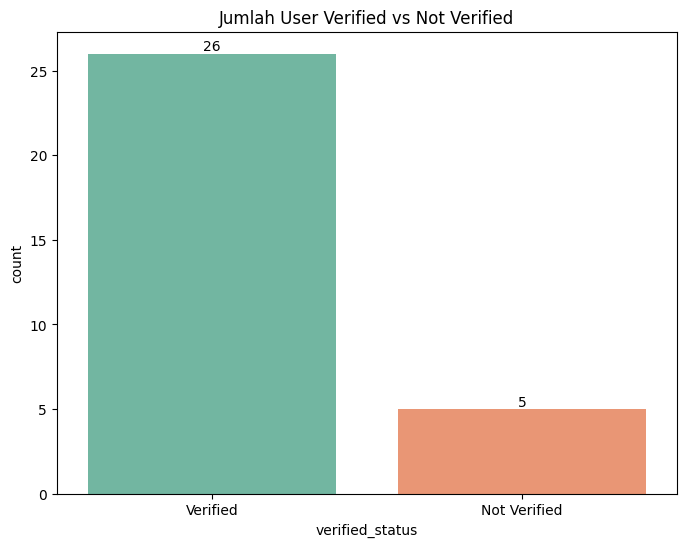

In [576]:
# User verified vs User not verified
user_filter['verified_status'] = user_filter['verified_at'].notnull().map({True: 'Verified', False: 'Not Verified'})

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=user_filter, x='verified_status')
sns.countplot(data=user_filter, x='verified_status', palette='Set2')
ax.bar_label(ax.containers[0], padding=0)
plt.title("Jumlah User Verified vs Not Verified")
plt.show()

💡Penjelasan: <br>
Sebagian besar pengguna `(~84% atau 26 user)` telah melakukan verifikasi akun. Hanya sebagian kecil `(~16% atau 5 user)` yang statusnya Not Verified. Jumlah Not Verified (5 user) berkorelasi lurus dengan persentase missing values pada kolom verified_at `(16.1%)`. Ini mengonfirmasi bahwa nilai null pada kolom tersebut `bukan error`, melainkan indikator status pengguna yang belum terverifikasi

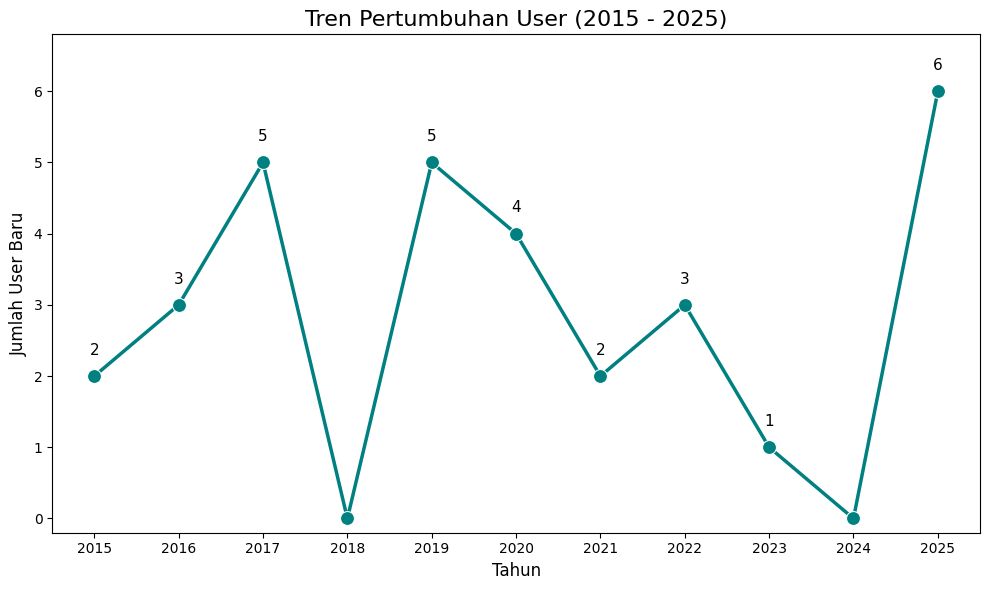

In [577]:
# Tren Pertumbuhan User Baru per Tahun
year_created = user_filter['created_at'].dt.year
yearly_counts_series = year_created.value_counts().sort_index()

min_year = yearly_counts_series.index.min()
max_year = yearly_counts_series.index.max()
all_years = range(min_year, max_year + 1)

yearly_counts_series = yearly_counts_series.reindex(all_years, fill_value=0)
yearly_counts = yearly_counts_series.reset_index()
yearly_counts.columns = ['year', 'count']

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=yearly_counts, 
    x='year', 
    y='count', 
    marker='o', 
    markersize=10, 
    linewidth=2.5, 
    color='teal'
)

for x, y in zip(yearly_counts['year'], yearly_counts['count']):
    if y > 0: 
        plt.text(x, y + 0.3, str(int(y)), ha='center', fontsize=11)

max_y = yearly_counts['count'].max()
plt.ylim(-0.2, max_y + 0.8)

plt.title("Tren Pertumbuhan User (2015 - 2025)", fontsize=16)
plt.xlabel("Tahun", fontsize=12)
plt.ylabel("Jumlah User Baru", fontsize=12)
plt.xticks(yearly_counts['year']) 

plt.tight_layout()
plt.show()

- developer_journeys

In [578]:
# Struktur Data
journeys_cleaning.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176 entries, 0 to 175
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          176 non-null    int64         
 1   name                        176 non-null    object        
 2   summary                     176 non-null    object        
 3   point                       176 non-null    int64         
 4   required_point              176 non-null    int64         
 5   xp                          176 non-null    int64         
 6   required_xp                 176 non-null    int64         
 7   difficulty                  176 non-null    int64         
 8   created_at                  176 non-null    datetime64[ns]
 9   updated_at                  176 non-null    datetime64[ns]
 10  instructor_id               176 non-null    int64         
 11  deadline                    176 non-null    int64         

In [579]:
# Missing Value
journeys_cleaning.isnull().mean().sort_values(ascending=False)

recommended_hours_per_week    0.477273
estimated_days                0.465909
name                          0.000000
id                            0.000000
summary                       0.000000
point                         0.000000
required_xp                   0.000000
difficulty                    0.000000
required_point                0.000000
xp                            0.000000
updated_at                    0.000000
created_at                    0.000000
instructor_id                 0.000000
deadline                      0.000000
graduation                    0.000000
type                          0.000000
teaching_method_clean         0.000000
hours_to_study                0.000000
dtype: float64

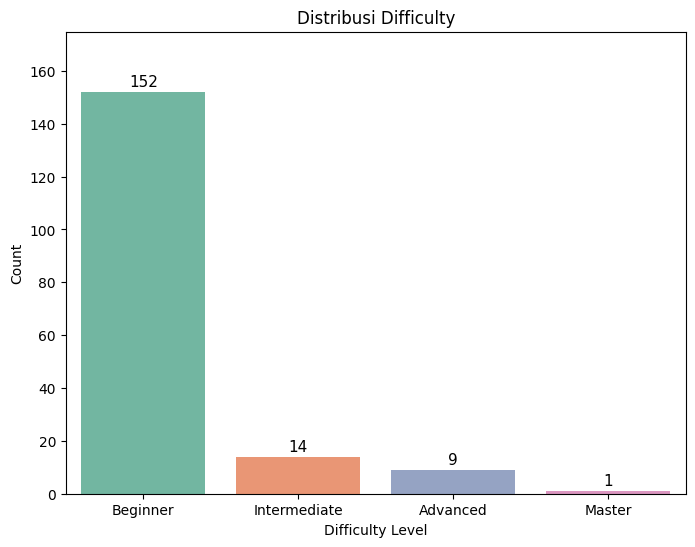

In [580]:
# Distribusi difficulty level
difficulty_map = {0: 'Beginner', 1: 'Intermediate', 2: 'Advanced', 3: 'Master'}
difficulty_series = journeys_cleaning['difficulty'].map(difficulty_map)
order_list = ['Beginner', 'Intermediate', 'Advanced', 'Master']

plt.figure(figsize=(8, 6))

ax = sns.countplot(
    x=difficulty_series, 
    order=order_list,
    palette='Set2' 
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=11, 
                    color='black',
                    xytext=(0, 2), 
                    textcoords='offset points')

plt.ylim(0, difficulty_series.value_counts().max() * 1.15)

plt.title("Distribusi Difficulty")
plt.xlabel("Difficulty Level")
plt.ylabel("Count")

plt.show()

💡Penjelasan: <br>
Sangat Terfokus pada Pemula Kurikulum didominasi oleh level Beginner `(86%)`, dengan penurunan drastis pada ketersediaan konten untuk level Intermediate hingga Master. Ini menunjukkan platform sangat kuat dalam user acquisition (pendatang baru) namun memiliki risiko tinggi kehilangan pengguna (churn) yang ingin naik kelas ke tingkat mahir

In [581]:
# Statistik estimasi durasi course/journey
journeys_cleaning[['hours_to_study', 
             'recommended_hours_per_week', 
             'estimated_days']].describe()

,hours_to_study,recommended_hours_per_week,estimated_days
count,176.000000,92.000000,94.000000
mean,30.011364,9.750000,31.489362
std,31.853771,1.371812,22.133876
min,0.000000,2.000000,2.000000
25%,2.000000,10.000000,12.000000
50%,19.000000,10.000000,28.000000
75%,45.000000,10.000000,49.000000
max,150.000000,10.000000,105.000000


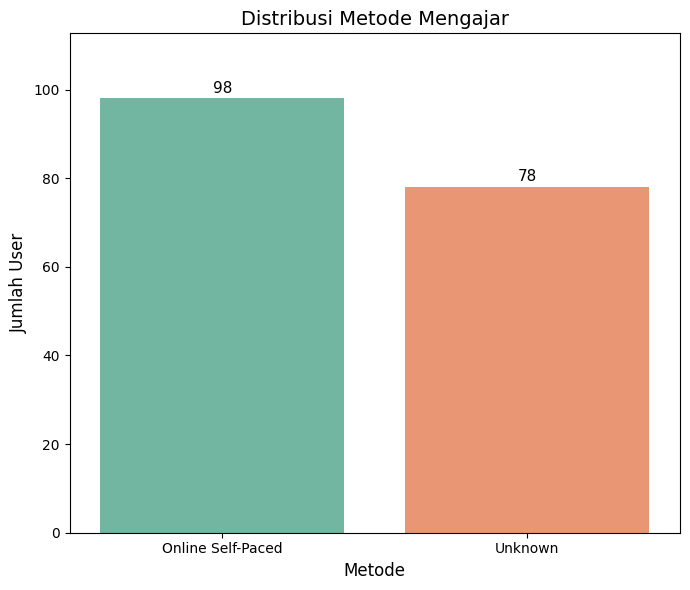

In [590]:
# Distribusi Metode Mengajar (Teaching Methods)
teach_method = journeys_cleaning['teaching_method_clean'].str.title()

plt.figure(figsize=(7, 6)) 

ax = sns.countplot(
    x=teach_method,      
    palette='Set2',     
    order=teach_method.value_counts().index
)

for container in ax.containers:
    ax.bar_label(container, padding=2, fontsize=11)

plt.ylim(0, teach_method.value_counts().max() * 1.15)

plt.title("Distribusi Metode Mengajar", fontsize=14)
plt.xlabel("Metode", fontsize=12)
plt.ylabel("Jumlah User", fontsize=12)

plt.tight_layout()
plt.show()

💡Penjelasan: <br>
Metode pengajaran utama adalah Online Self-Paced, memberikan fleksibilitas penuh pada siswa. Secara statistik, mayoritas kelas dirancang "ringan" dengan median durasi belajar `19 jam` dan standar rekomendasi beban studi `10 jam/minggu`.

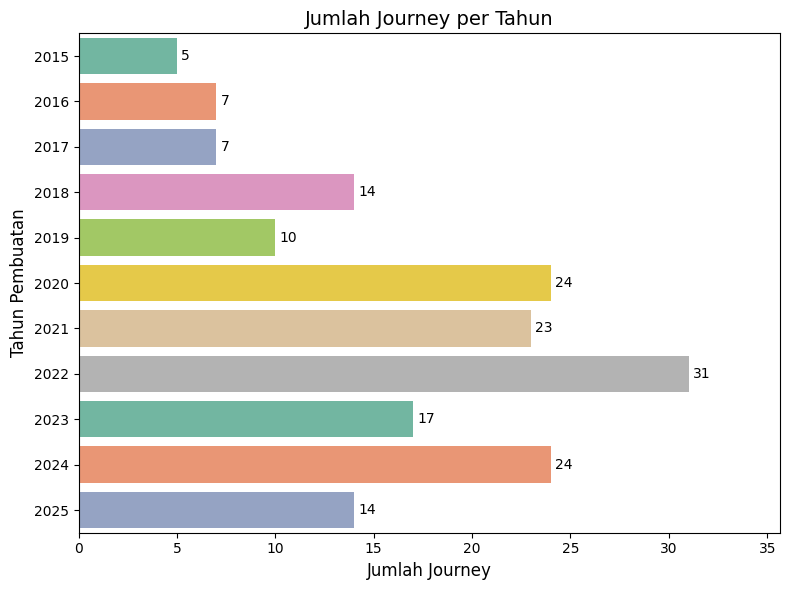

In [589]:
# Jumlah Journey per Tahun
journey_year = journeys_cleaning['created_at'].dt.year

plt.figure(figsize=(8, 6))

ax = sns.countplot(
    y=journey_year, 
    palette='Set2' 
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

max_count = journey_year.value_counts().max()
plt.xlim(0, max_count * 1.15)

plt.title("Jumlah Journey per Tahun", fontsize=14)
plt.xlabel("Jumlah Journey", fontsize=12)
plt.ylabel("Tahun Pembuatan", fontsize=12)

plt.tight_layout()
plt.show()

💡Penjelasan: <br>
Produktivitas tim kurikulum mencapai puncaknya pada tahun 2022 (31 journey). Sempat mengalami penurunan signifikan di 2023, namun tren kembali positif (rebound) di tahun 2024, menandakan adanya pemulihan fokus pada pengembangan materi baru

- developer_journey_tutorials

In [593]:
# Jumlah materi/modul per journey/kelas
tutorials_cleaning['developer_journey_id'].value_counts().head(10)

developer_journey_id
219    289
271    197
14     193
163    179
266    170
123    169
80     169
610    155
256    154
209    144
Name: count, dtype: int64

💡Penjelasan: <br>
Terdapat perbedaan signifikan dalam jumlah modul per kelas. Kelas terpadat (id: 219) memiliki 289 modul, sementara kelas-kelas populer lainnya berkisar antara 140-190 modul

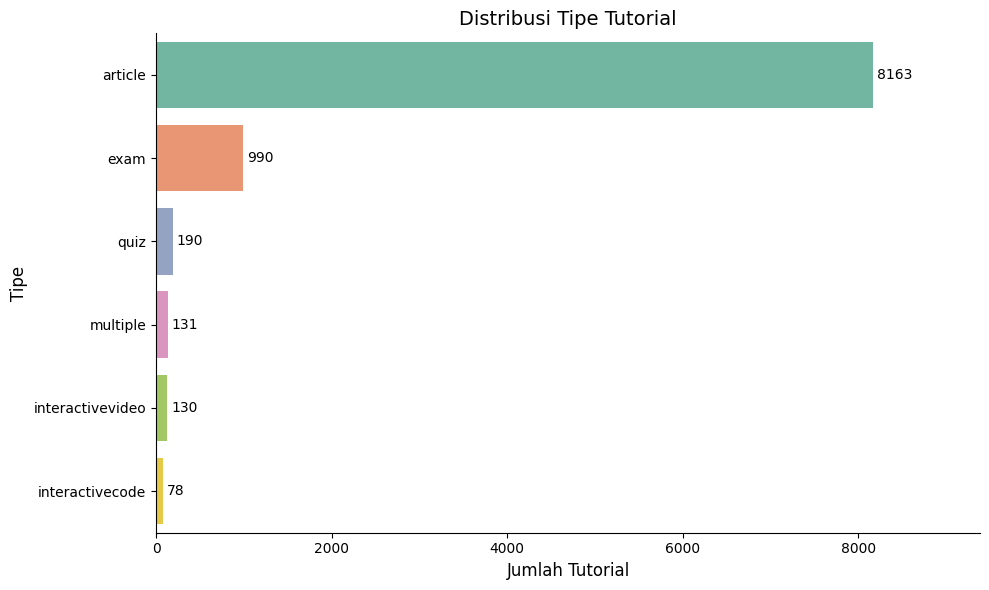

In [611]:
# Distribusi tipe materi/modul
tutorial_type = tutorials_cleaning['type'].value_counts()

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=tutorial_type.values, 
    y=tutorial_type.index, 
    palette='Set2' 
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.xlim(0, tutorial_type.values.max() * 1.15)

plt.title("Distribusi Tipe Tutorial", fontsize=14)
plt.xlabel("Jumlah Tutorial", fontsize=12)
plt.ylabel("Tipe", fontsize=12)

sns.despine()

plt.tight_layout()
plt.show()

💡Penjelasan: <br>
- Platform sangat didominasi oleh artikel teks (8.163 tutorial), jauh melampaui format interaktif seperti Exam (990) atau Quiz (190)
- Format interaktif yang krusial untuk skill coding (Interactive Code, Interactive Video) jumlahnya sangat minim (<150)
- Perlu strategi diversifikasi konten. Menambah porsi Interactive Code akan meningkatkan engagement dan retensi materi teknis.

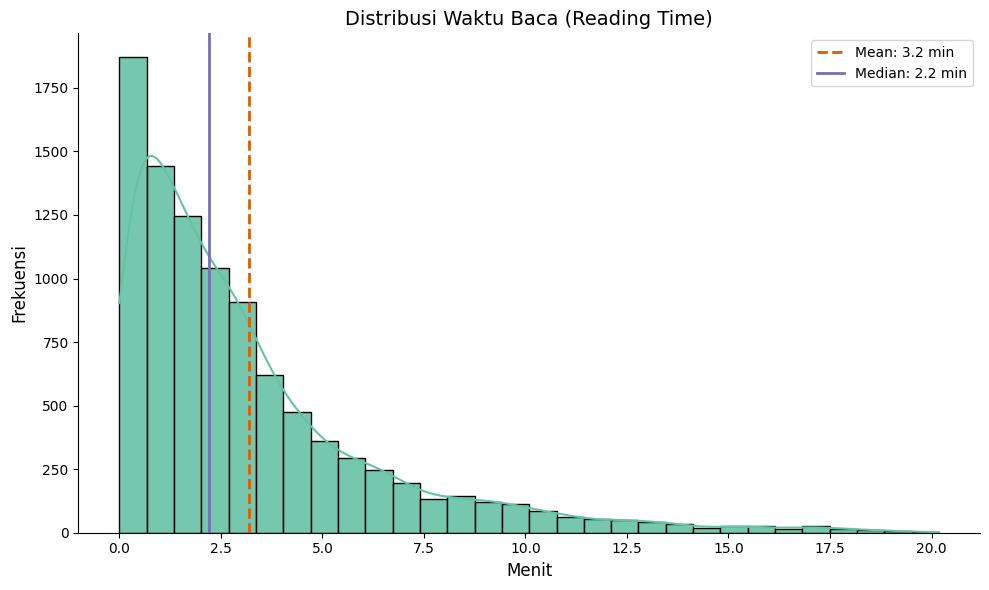

In [613]:
# Distribusi waktu baca
plt.figure(figsize=(10, 6))

color_theme = sns.color_palette("Set2")[0] 

sns.histplot(
    data=tutorials_cleaning,
    x='reading_time_minutes',
    bins=30,
    kde=True,
    color=color_theme,
    alpha=0.9         
)

mean_val = tutorials_cleaning['reading_time_minutes'].mean()
median_val = tutorials_cleaning['reading_time_minutes'].median()

plt.axvline(mean_val, color='#d95f02', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f} min')
plt.axvline(median_val, color='#7570b3', linestyle='-', linewidth=2, label=f'Median: {median_val:.1f} min')

plt.title("Distribusi Waktu Baca (Reading Time)", fontsize=14)
plt.xlabel("Menit", fontsize=12)
plt.ylabel("Frekuensi", fontsize=12)

plt.legend()
sns.despine()

plt.tight_layout()
plt.show()

💡Penjelasan: <br>
- Distribusi waktu baca sangat miring ke kiri (positively skewed) dengan Median 2.2 menit. Mayoritas materi dirancang untuk dibaca cepat
- Rata-rata (Mean) durasi adalah 3.2 menit, yang konsisten dengan standar industri micro-learning. Ini memudahkan siswa mencicil belajar di sela waktu sibuk

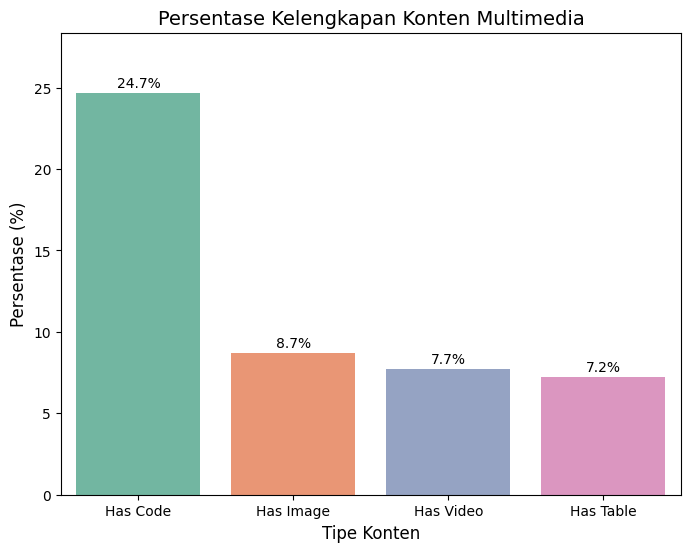

In [617]:
# Kelengkapan konten multimedia pada setiap modul/materi
richness_metrics = tutorials_cleaning[['has_image', 'has_video', 'has_code', 'has_table']].mean() * 100
richness_metrics = richness_metrics.sort_values(ascending=False)
richness_metrics.index = richness_metrics.index.str.replace('_', ' ').str.title()

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    x=richness_metrics.index, 
    y=richness_metrics.values,
    palette='Set2'
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=10, color='black',
                xytext=(0, 2), 
                textcoords='offset points')

plt.title("Persentase Kelengkapan Konten Multimedia", fontsize=14)
plt.ylabel("Persentase (%)", fontsize=12)
plt.xlabel("Tipe Konten", fontsize=12) 

plt.ylim(0, richness_metrics.max() * 1.15) 

plt.show()

💡Penjelasan: <br>
Dengan `>90%` konten tanpa visual pendukung, materi berisiko membosankan dan sulit dipahami bagi pembelajar visual

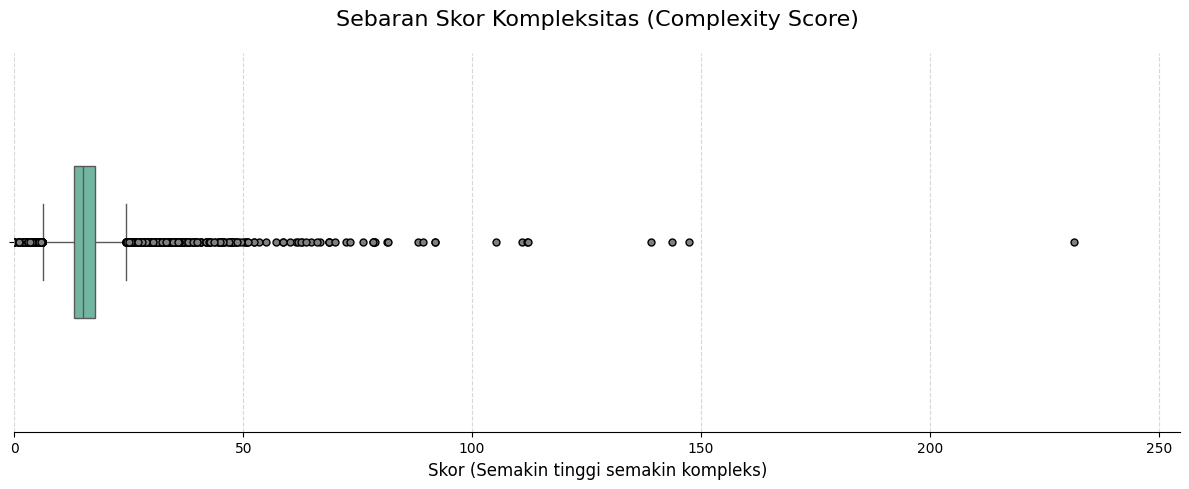

In [625]:
# Sebaran skor kompleksitas (complexity score) pada materi/modul
plt.figure(figsize=(12, 5)) 

plot_color = sns.color_palette("Set2")[0] 

ax = sns.boxplot(
    x=tutorials_cleaning['complexity_score'], 
    color=plot_color,
    width=0.4,
    linewidth=1,
    flierprops=dict(marker='o', markersize=5, markerfacecolor='grey', markeredgecolor='black')
)

plt.title("Sebaran Skor Kompleksitas (Complexity Score)", fontsize=16, pad=20, loc='center')
plt.xlabel("Skor (Semakin tinggi semakin kompleks)", fontsize=12)
plt.ylabel("") 

plt.grid(axis='x', linestyle='--', alpha=0.5) 
plt.xlim(0, tutorials_cleaning['complexity_score'].max() * 1.1)
sns.despine(left=True, bottom=False) 

plt.tight_layout()
plt.show()

💡Penjelasan: <br>
- Sebagian besar materi memiliki skor kompleksitas yang seragam dan rendah (terpusat di area kiri boxplot)
- Terdapat sejumlah materi dengan skor kompleksitas sangat tinggi (>100 hingga 230) yang jauh dari rata-rata
- Materi-materi berpotensi menjadi hambatan (blocker) pemahaman pengguna/developer